## Logistic Regression on Iris Dataset

In [10]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

iris = load_iris()
X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y
df['target_names'] = df['target'].apply(lambda x: iris.target_names[x])

display(df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 120 samples
Test set size: 30 samples


In [7]:
model = LogisticRegression(max_iter=200, random_state=42)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200, random_state=42)

In [8]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy on the test set: {accuracy:.4f}")

Model Accuracy on the test set: 1.0000


In [9]:
sample_indices = [0, 5, 10]
sample_features = X_test[sample_indices]
sample_true_labels = y_test[sample_indices]
sample_predicted_labels = model.predict(sample_features)

for i, (features, true_label, predicted_label) in enumerate(zip(sample_features, sample_true_labels, sample_predicted_labels)):
    print(f"Sample {i+1}:")
    print(f"Features: {features}")
    print(f"True Class: {iris.target_names[true_label]} (ID: {true_label})")
    print(f"Predicted Class: {iris.target_names[predicted_label]} (ID: {predicted_label})")

Sample 1:
Features: [6.1 2.8 4.7 1.2]
True Class: versicolor (ID: 1)
Predicted Class: versicolor (ID: 1)
Sample 2:
Features: [5.4 3.4 1.5 0.4]
True Class: setosa (ID: 0)
Predicted Class: setosa (ID: 0)
Sample 3:
Features: [6.5 3.2 5.1 2. ]
True Class: virginica (ID: 2)
Predicted Class: virginica (ID: 2)


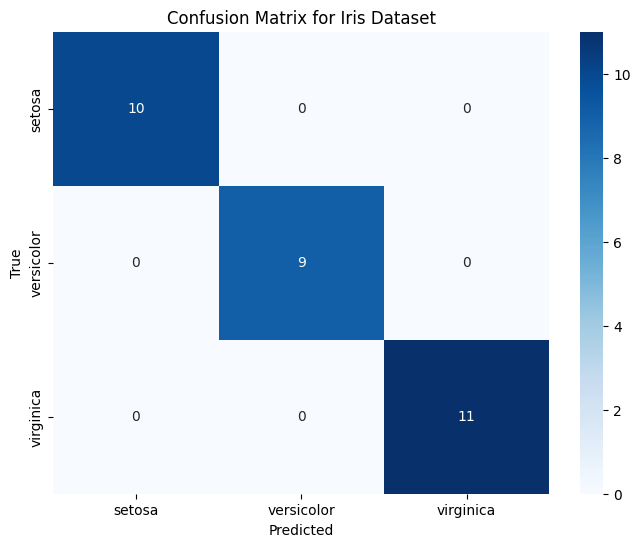

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Iris Dataset')
plt.show()